# Square Root

Your task is to calculate the square root of a given number.

Try to avoid using the pre-existing math libraries of your language.
As input you'll be given a positive whole number, i.e. 1, 2, 3, 4…
You are only required to handle cases where the result is a positive whole number.
Some potential approaches:

Linear or binary search for a number that gives the input number when squared.
Successive approximation using Newton's or Heron's method.
Calculating one digit at a time or one bit at a time.

### Intuitive solution

Given a positive number $r$, let $a$ be the greatest positive integer such that $a^2 \leq r$ and $b$ be the smallest positive integer such that $r \leq b^2 $.

For example, if $r = 11$, than $a = 3$ and $b = 4$, because $a^2 = 9 < 11 < 16 = b^2$. Let $x = \dfrac{a + b}{2}$ be our first computation and $\epsilon > 0$ be our tolerance/precision. 

Than, we execute the following algorithm:

While $|x^2 - r| > \epsilon$:
- If ${x}^2 < r$: 

$~~~~~~~~~~~~$ $a \leftarrow x$

- If ${x}^2 > r$:

$~~~~~~~~~~~~$ $b \leftarrow x$

- $x \leftarrow \dfrac{a + b}{2}$


In [365]:
def findSquareRoot(r, epsilon):
    # Finding initial values to "a" and "b"
    b = 1
    while(b**2 <= r):
        b += 1
    if(r == b**2): return b
    a = b - 1
    x = (a + b)/2
    iter = []
    while(abs(x**2 - r) > epsilon):
        iter.append(x)
        if(x**2 < r):
            a = x
        else:
            b = x
        x = (a + b)/2

    return(x, iter)

In [366]:
r = 2
x, iter = findSquareRoot(r, 1e-3)

print("x = ", x)
print("Number of iterations: ", len(iter))
print("Difference: ", abs(x**2 - r))

x =  1.4140625
Number of iterations:  6
Difference:  0.00042724609375


### Analysis solution

Let $r > 0$ and consider the following sequence $x_{n+1} = \dfrac{1}{2}\left(x_n + \dfrac{r}{x_n}\right)$, with $x_0 > 0$.

It's easy to verify that $x_n > 0$ for all $n \in \mathbb{N}$, which implies the sequence is well defined (Division by 0 does not occur).

Notice that we can write the sequence as $(2x_{n+1} - x_n)x_n = r > 0$

$\Rightarrow 2x_{n+1}x_n - x_n ^2 =  r\\
$

We know that $0 \leq (a-b)^2 = a^2 - 2ab + b^2 \Rightarrow a^2 + b^2 \geq 2ab$, for all $a, b$ real numbers.

Then:

$(x_{n+1}^2 + x_{n}^2) -  x_{n}^2\geq 2x_{n+1}x_n - x_n ^2 = r$
$\Rightarrow x_{n+1}^2 \geq r$ for all $n \in \mathbb{N}$

This implies that $x_{n+1} = \dfrac{1}{2}\left(x_n + \dfrac{r}{x_n}\right) \leq \dfrac{1}{2}\left(x_n + \dfrac{{x_n}^2}{x_n}\right)$

$\Rightarrow x_{n+1} \leq x_n$ for all $n \geq 1$

Since the sequence does not grow and has a lower bound (because $x_n > 0$ for all $n$), it's known from a result from mathematical analysis, that this sequence converges.

In other words, this proves that $L := \displaystyle\lim_{n\rightarrow \infty} x_n$ existis.

Also $L > 0$, because $x_n^2 \geq r > 0 \Rightarrow \displaystyle\lim_{n\rightarrow \infty}x_n^2 \geq r > 0 \Leftrightarrow (\displaystyle\lim_{n\rightarrow \infty}x_n)^2 = L^2\geq r > 0$, and since $x_n > 0 $ for all $n$ (which imples $L \geq 0$), we conclude that $L>0$.

Finally, with some limit proprieties and the fact that $\displaystyle\lim_{n\rightarrow \infty} x_{n+1} = \displaystyle\lim_{n\rightarrow \infty} x_n = L$, we can calculate the limit of the sequence by replacing $x_{n+1}$ and $x_n$ by $L$, giving:

$L= \dfrac{1}{2}\left(L + \dfrac{r}{L}\right)\Rightarrow 2L = \dfrac{L^2 + r}{L}\Rightarrow 2L^2 - L^2 = r$

$\therefore L^2 = r$

In other words, the sequence converges to the square root of $r$.









In [367]:
def seq_xn(r, x0, epsilon):
    xn = x0
    if(x0 <= 0):
        raise Exception("x0 must be a positive number")
    iter = []
    while(abs(xn**2 - r) > epsilon):
        iter.append(xn)
        xn = (1/2)*(xn + r/xn) 
    return(xn, iter)

In [368]:
r = 2
x1 = 1
L, iter = seq_xn(r, x1, 1e-3)

print("x = ", L)
print("Number of iterations: ", len(iter))
print("Difference: ", abs(L**2 - r))

x =  1.4142156862745097
Number of iterations:  3
Difference:  6.007304882427178e-06


### Newton's method

Find the square root of a positive number $r \in \mathbb{R}$ is equivalent to find the root of the function $f(x) = x^2 - r$

Knowing this, we can use numerical methods to find $\bar{x} \in \mathbb{R}$ which $f(\bar{x}) = 0$. For this particular function, $|\bar{x}|$ is the square root of r.

Given a number $x_n \in \mathbb{R}$, with differential calculus we can find the tangent line to $f$ at the point $x_n$, which is given by:

$
r_{f(x_n)}(x) = f'(x_n)(x - x_n) + f(x_n) 
$

Let $x_{n+1}$ be the value where $r_{f(x_n)}(x_{n+1}) = 0$. Then, we have:

$x_{n + 1} = x_n - \dfrac{f(x_n)}{f'(x_n)}.
$

Newton's method is given by choosing a initial value $x_0 \in \mathbb{R}$ and proceding with the above rule such that $f'(x_n) \neq 0$ for all $n\in \mathbb{N}$.

The iteration stops when it reaches a maximum number of steps.

For our function, we can break the iterations when $|x_{n}^2 - r| \leq \epsilon$, where $\epsilon > 0$ is our tolerance/precision.


In [369]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axisartist.axislines import AxesZero
import textalloc as ta

In [370]:
def f(x, r):
    return x**2 - r

def df(x, r):
    return 2*x

def tangentLine(f, df, x_0, x, r):
    return(df(x_0, r)*(x - x_0) + f(*[x_0, r]))

def newtonMethod(fun, dfun, r, x0 = 1, n = 1e3, epsilon = 1e-3):
    iter = []
    x = x0
    i = 0
    while(i < n):
        if(dfun(*[x, r]) == 0):
            raise Exception("Not a valid x0. df equals 0 at " + str(i) + "-th iteration")
        iter.append(x)
        x = x - fun(*[x, r])/dfun(*[x, r])
        i += 1
        if(abs(x - iter[-1]) <= epsilon):
            break
    return(x, iter)

Text(4.47213595499958, -5, '$\\sqrt{r}$')

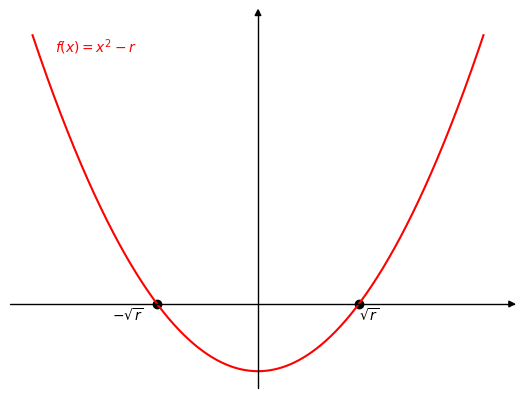

In [371]:
fig = plt.figure()
ax = fig.add_subplot(axes_class=AxesZero)
for direction in ["xzero", "yzero"]:
    # adds arrows at the ends of each axis
    ax.axis[direction].set_axisline_style("-|>")

    # adds X and Y-axis from the origin
    ax.axis[direction].set_visible(True)

for direction in ["left", "right", "bottom", "top"]:
    ax.axis[direction].set_visible(False)

r = 20
X = np.linspace(-10, 10, 1000)
ax.plot(X, f(X, r), c = 'r')
ax.scatter([-r**(1/2), r**(1/2)], [0, 0], c = 'k')

ax.axes.get_xaxis().set_ticks([])
ax.axes.get_yaxis().set_ticks([])
ax.text(-9, 75, r"$f(x) = x^2 - r$", c = 'r')
ax.text(-r**(1/2) - 2, -5, r"$-\sqrt{r}$")
ax.text(r**(1/2), -5, r"$\sqrt{r}$")

    

x_bar =  1.4142135623746899
x_bar^2 =  2.0000000000045106


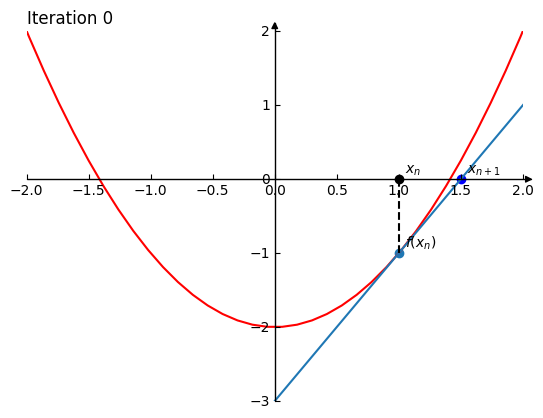

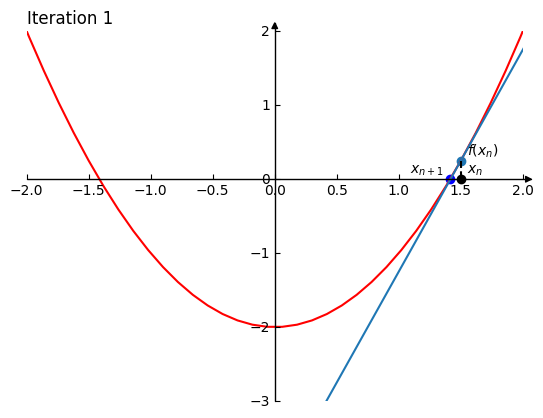

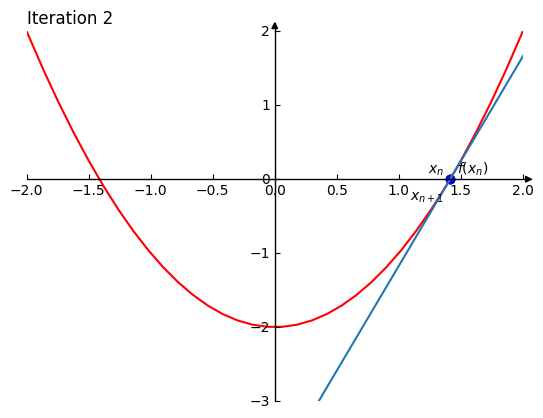

In [372]:
r = 2
xLim, yLim = 2, 2
x_0 = 1

# r = 2
# xLim, yLim = 10, 20
# x_0 = 4

# r = 5
# xLim, yLim = 10, 20
# x_0 = 4

x_bar, iter = newtonMethod(f, df, r, x_0)

print("x_bar = ", x_bar)
print("x_bar^2 = ", x_bar**2)

X = np.linspace(-60, 60, 1000)

# for i, ax in enumerate(axs.reshape(-1)):
for i in range(0, len(iter) - 1):
    # fig, ax = plt.subplots()
    # ax = fig.add_subplot(axes_class=AxesZero)
    fig = plt.figure()
    ax = fig.add_subplot(axes_class=AxesZero)
    for direction in ["xzero", "yzero"]:
        # adds arrows at the ends of each axis
        ax.axis[direction].set_axisline_style("-|>")

        # adds X and Y-axis from the origin
        ax.axis[direction].set_visible(True)

    for direction in ["left", "right", "bottom", "top"]:
        ax.axis[direction].set_visible(False)

    plt.title("Iteration " + str(i), loc = 'left')
    ax.set_ylim(-(r + 1), yLim)

    ax.set_xlim(-xLim, xLim)
    ax.plot(X, f(X, r), c = 'r')
    ax.plot(X, tangentLine(f, df, iter[i], X, r))

    ax.scatter(iter[i], tangentLine(f, df, iter[i], iter[i], r))
    ax.scatter(iter[i], 0, c = 'k')
    ax.scatter(iter[i + 1], 0, c = 'b')

    ax.plot([iter[i],  iter[i]],
                  [0, tangentLine(f, df, iter[i], iter[i], r)],
                  c = 'k', linestyle = '--')
    texts = [r'$f(x_n)$',
             r'$x_{n}$',
              r'$x_{n + 1}$']
    
    x_lineText = [iter[i], iter[i], iter[i + 1]]
    ta.allocate(ax, x_lineText, [f(iter[i], r), 0, 0], texts, draw_lines = False)

    plt.show()

## The plot twist

We didn't know where the sequence from the Analysis Solution came from, just why it works.

On the other hand, we can deduce Newton's method and how the sequence is generted, but we don't know exactly why it converges.

The catch, is that they are the same methods!

If $f(x) = x^2 - r$, we have $f'(x) = 2x$.

Plugging those functions in $x_{n + 1} = x_n - \dfrac{f(x_n)}{f'(x_n)}$, we have:

$x_{n+1} = x_{n} - \dfrac{x_n^2 - r}{2x_n}$

$\Rightarrow x_{n+1} = x_{n} - \dfrac{x_n^2}{2x_n} + \dfrac{r}{2x_n}$

$\Rightarrow x_{n+1} = \dfrac{2x_{n} - x_n}{2} + \dfrac{r}{2x_n}$

$\Rightarrow x_{n+1} = \dfrac{x_{n}}{2} + \dfrac{r}{2x_n}$

$\Rightarrow x_{n+1} = \dfrac{1}{2}\left(x_{n} + \dfrac{r}{x_n}\right)$

Which is the sequence we saw before.

Therefore, we must choose some initial value $x_0 > 0$ for Newton's method. This is important because it guarantees that it will converges, \
as we proved. This is not always the case: depending on the function or the initial value, Newton's method may not converge. But when it does\
it converges really fast!